# pigsim surrogate — short demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NNOOHHDD/pigsim-surrogate/blob/main/notebooks/demo.ipynb)

Three things with the saved models, each checked against one fresh pigsim run (~10 s each):

1. predict arrival time and peak speed (stage 2 MLP ensemble + arrival classifier)
2. inverse design: the lowest inlet pressure that gets the pig through in time
3. the whole pig-speed curve (stage 3 DeepONet)

Inputs: inlet pressure `p_in`, pig mass, pig friction `F_fric`, pipe length `L` of the
generic test line in `surrogate/pipeline.py`.

In [1]:
import os, sys

if "google.colab" in sys.modules and not os.path.exists("/content/pigsim-surrogate"):
    !git clone -q https://github.com/NNOOHHDD/pigsim-surrogate /content/pigsim-surrogate
    %cd /content/pigsim-surrogate
    !pip install -q "mcp[cli]<2"

ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()) == "notebooks" else ".")
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import matplotlib.pyplot as plt
from surrogate import registry
from mcp_server import tools

## 1. Predict, then check with pigsim

`tools.predict` uses bar / kg / kN / m and adds warnings (out of range, close to the start
threshold where the pig barely moves).

In [2]:
x = dict(p_in_bar=5.5, mass_kg=110, F_fric_kN=3.5, L_m=1750)
pred = tools.predict(**x)
sim = tools.run_pigsim(**x)
print(f"surrogate: t_arrive {pred['t_arrive_s']['mean']:.1f} ± {pred['t_arrive_s']['std']:.1f} s, "
      f"v_max {pred['v_max_m_s']['mean']:.2f} ± {pred['v_max_m_s']['std']:.2f} m/s, "
      f"P(arrive) {pred['p_arrive']:.3f}")
print(f"pigsim   : t_arrive {sim['t_arrive_s']:.1f} s, v_max {sim['v_max_m_s']:.2f} m/s ({sim['wall_s']} s wall)")
print("warnings :", pred["warnings"])

surrogate: t_arrive 99.4 ± 0.2 s, v_max 69.44 ± 0.06 m/s, P(arrive) 1.000
pigsim   : t_arrive 99.4 s, v_max 69.33 m/s (11.41 s wall)
warnings : []


In [3]:
# close to the start threshold the surrogate is much less sure (and still too confident)
print(tools.predict(p_in_bar=2.2, mass_kg=110, F_fric_kN=3.5, L_m=1750)["warnings"])

['Only 0.106 bar above the start threshold: expect 1-13 % error and a std that is too small.']


## 2. Inverse design

Lowest inlet pressure (mass and friction free within their ranges) that gets the pig through
2 km within 300 s. Constraints: arrival classifier P ≥ 0.95, training range, and
`t + k_sigma·std ≤ 300 s`; the best design is re-run in pigsim. With `k_sigma = 2` the answer
landed exactly on the boundary and missed by 0.02 s in pigsim (see `README_mcp.md`), so a
3-std margin is used here.

In [4]:
r = tools.inverse_design(L_m=2000, t_max_s=300, k_sigma=3.0, n_starts=64)
b, c = r["best"], r["pigsim_check"]
print(f"best design: p_in {b['p_in_bar']:.3f} bar, mass {b['mass_kg']:.0f} kg, friction {b['F_fric_kN']:.2f} kN")
print(f"surrogate  : t_arrive {b['predicted']['t_arrive_s']:.1f} ± {b['predicted']['t_arrive_std']:.1f} s")
print(f"pigsim     : t_arrive {c['t_arrive_s']:.1f} s -> meets target: {c['meets_targets']}")

best design: p_in 2.408 bar, mass 126 kg, friction 1.04 kN
surrogate  : t_arrive 290.5 ± 2.8 s
pigsim     : t_arrive 296.9 s -> meets target: True


## 3. The whole speed curve

The stage-3 DeepONet ensemble predicts the pig speed at 128 positions
ξ = (s − s₀)/(0.999 L − s₀), dense near the start. Here it is compared with a fresh pigsim run
at an input it was not trained on.

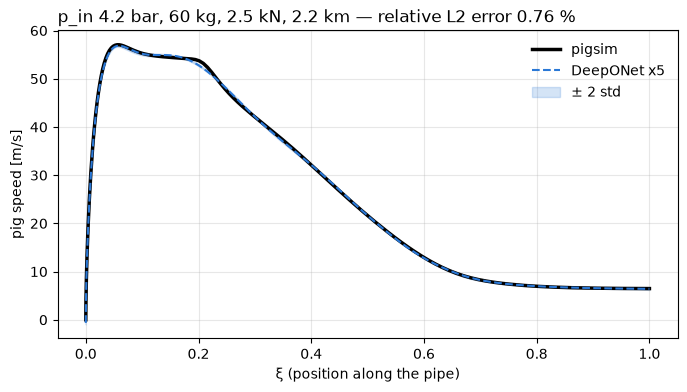

In [5]:
from surrogate.stage3.generate_curves import run_one

xs = np.array([4.2e5, 60.0, 2500.0, 2200.0])          # p_in [Pa], mass, F_fric [N], L [m]
_, _, true = run_one((0, xs))
model = registry.deeponet()
mean, std = model.predict(xs[None, :])
err = np.sqrt(np.trapezoid((mean[0] - true["V"]) ** 2, model.xi) / np.trapezoid(true["V"] ** 2, model.xi))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.xi, true["V"], color="k", lw=2.5, label="pigsim")
ax.plot(model.xi, mean[0], color="#2a78d6", lw=1.5, ls="--", label="DeepONet x5")
ax.fill_between(model.xi, mean[0] - 2 * std[0], mean[0] + 2 * std[0], color="#2a78d6", alpha=0.2,
                label="± 2 std")
ax.set_xlabel("ξ (position along the pipe)"); ax.set_ylabel("pig speed [m/s]")
ax.set_title(f"p_in 4.2 bar, 60 kg, 2.5 kN, 2.2 km — relative L2 error {100 * err:.2f} %", loc="left")
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.show()

More: `surrogate/RESULTS.md` (stages 1–2), `surrogate/stage3/RESULTS_stage3.md`,
`anomaly/RESULTS_anomaly.md`, and `README_mcp.md` for using the same tools from Claude.